In [2]:
import numpy as np
from scipy.optimize import minimize_scalar
from ridge_losso import ridge, lasso
import matplotlib.pyplot as plt

In [3]:
vec = np.array([[1,0,1], [0,1,5], [1,1,2]])

In [4]:
Y = vec[:,2]
X = vec[:,[0,1]]

$$\hat{\beta} = F^{-1} \Psi^T Y$$

In [5]:
U = X
F = U.T@U

b = np.linalg.inv(F)@U.T@Y

print(b)

[-0.33333333  3.66666667]


ridge: L = e^T*e + лямбда*бетта^T*бетта <= t
lasso: sum i = 1 - k |bi| <= t

lambda = minimize_scalar((Y - ))

In [6]:

from ridge_losso import ridge, lasso


def ridge_solution(alpha):
    n_features = U.shape[1]
    return np.linalg.inv(U.T @ U + alpha * np.eye(n_features)) @ U.T @ Y

def ridge_loss(alpha):
    b = ridge_solution(alpha)
    e = Y - U @ b
    return ridge(e, b, alpha)  

def lasso_loss(alpha):
    b = ridge_solution(alpha)  
    e = Y - U @ b
    return lasso(e, b, alpha) 

result_ridge = minimize_scalar(ridge_loss, bounds=(0, 10), method='bounded')


result_lasso = minimize_scalar(lasso_loss, bounds=(0, 10), method='bounded')



In [31]:
def CVSS_ridge(alpha):
    n = len(vec)
    cvss = 0
    
    for i in range(n):
        X_train = np.delete(X, i, axis=0)
        Y_train = np.delete(Y, i)
        
        n_features = X_train.shape[1]
        b = np.linalg.inv(X_train.T @ X_train + alpha * np.eye(n_features)) @ X_train.T @ Y_train
        
        y_pred = X[i] @ b
        
        cvss += (Y[i] - y_pred)**2
    
    return cvss

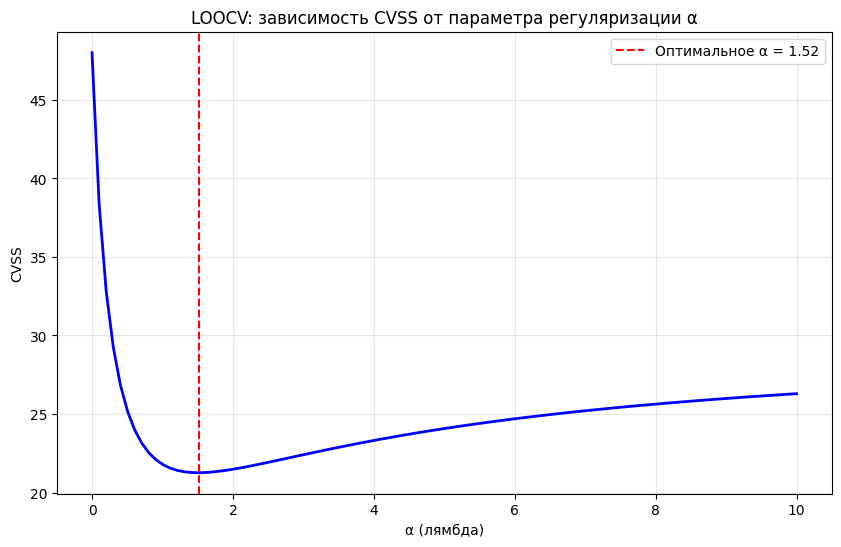

In [8]:
alphas = np.linspace(0, 10, 100)
cvss_values = [CVSS_ridge(a) for a in alphas]

plt.figure(figsize=(10, 6))
plt.plot(alphas, cvss_values, 'b-', linewidth=2)

optimal_idx = np.argmin(cvss_values)
optimal_alpha = alphas[optimal_idx]
plt.axvline(optimal_alpha, color='r', linestyle='--', 
            label=f'Оптимальное α = {optimal_alpha:.2f}')

plt.xlabel('α (лямбда)')
plt.ylabel('CVSS')
plt.title('LOOCV: зависимость CVSS от параметра регуляризации α')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
from sklearn.linear_model import Ridge, Lasso

In [51]:
def CVSS_lasso(alpha):
    CVSS = 0
    n = len(Y)

    for i in range(len(X)):
        Xi = np.delete(X, i, axis = 0)
        Yi = np.delete(Y, i)
        model = Lasso(alpha/(2*(n-1)), fit_intercept=False)
        model.fit(Xi, Yi)
        y_pred = model.predict(X[i].reshape(1,-1))
        CVSS += (y_pred[0] - Y[i])**2
    return CVSS


In [47]:
def CVSS_ridge(alpha):
    CVSS = 0
    for i in range(len(X)):
        Xi = np.delete(X, i, axis = 0)
        Yi = np.delete(Y, i)
        model = Ridge(alpha, fit_intercept=False)
        model.fit(Xi, Yi)
        y_pred = model.predict(X[i].reshape(1,-1))
        CVSS += (y_pred[0] - Y[i])**2
    return CVSS

In [48]:
# Потимальное значение alpha для ridge
alpha_opt_ridge = minimize_scalar(CVSS_ridge, bounds=(0,100), method = 'bounded')
print(alpha_opt_ridge)

 message: Solution found.
 success: True
  status: 0
     fun: 21.26505623796847
       x: 1.5056875596418147
     nit: 19
    nfev: 19


In [49]:
n = len(Y)
model = Ridge(alpha=alpha_opt_ridge.x, fit_intercept=False)
model.fit(X,Y)
model.coef_

array([0.31152444, 1.90789266])

In [53]:
alpha_opt_lasso = minimize_scalar(CVSS_lasso, bounds=(0,10), method = 'bounded')
print(alpha_opt_lasso)

 message: Solution found.
 success: True
  status: 0
     fun: 26.0
       x: 6.0
     nit: 6
    nfev: 6


In [54]:
model = Lasso(alpha=alpha_opt_lasso.x/(2*n), fit_intercept=False)
model.fit(X,Y)
model.coef_

array([0., 2.])

/home/daniil/Desktop/mipt/mat_stat/venv/lib/python3.12/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/daniil/Desktop/mipt/mat_stat/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/daniil/Desktop/mipt/mat_stat/venv/lib/python3.12/site-packages/sklearn/base.py:1336: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/daniil/Desktop/mipt/mat_stat/venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is disc

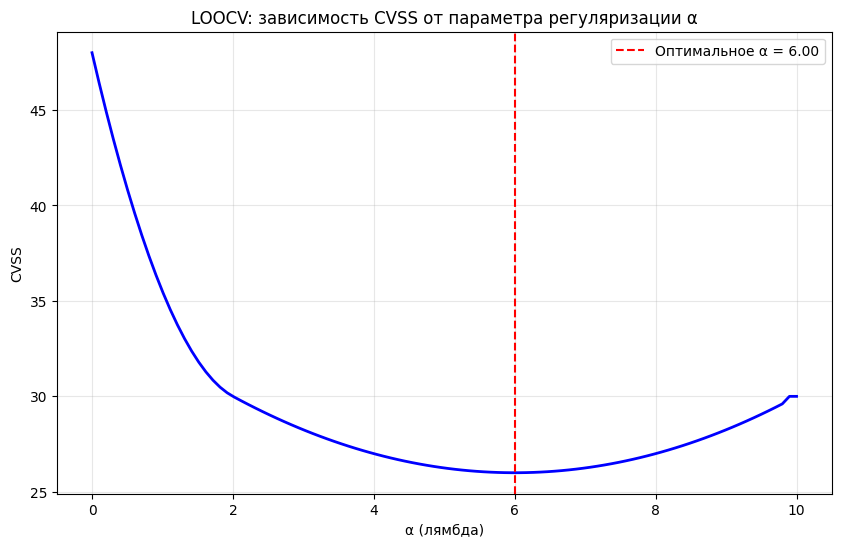

In [57]:
alphas = np.linspace(0, 10, 100)
cvss_values = [CVSS_lasso(a) for a in alphas]

plt.figure(figsize=(10, 6))
plt.plot(alphas, cvss_values, 'b-', linewidth=2)
plt.axvline(alpha_opt_lasso.x, color='r', linestyle='--', 
            label=f'Оптимальное α = {alpha_opt_lasso.x:.2f}')

plt.xlabel('α (лямбда)')
plt.ylabel('CVSS')
plt.title('LOOCV: зависимость CVSS от параметра регуляризации α')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

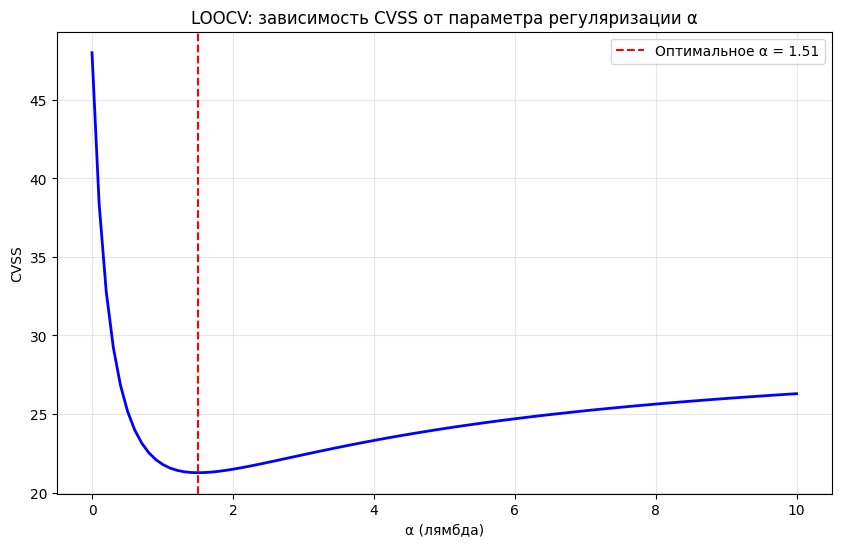

In [56]:
alphas = np.linspace(0, 10, 100)
cvss_values = [CVSS_ridge(a) for a in alphas]

plt.figure(figsize=(10, 6))
plt.plot(alphas, cvss_values, 'b-', linewidth=2)
plt.axvline(alpha_opt_ridge.x, color='r', linestyle='--', 
            label=f'Оптимальное α = {alpha_opt_ridge.x:.2f}')

plt.xlabel('α (лямбда)')
plt.ylabel('CVSS')
plt.title('LOOCV: зависимость CVSS от параметра регуляризации α')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()